# 📦 SYNTHETIC BLOCK MODEL GENERATOR

This notebook creates a **realistic, customisable 3D block model** for mining applications — simulating the spatial, geological, and economic characteristics found in operational mines.

Designed for concept testing, teaching, visualisation, or Mine-to-Mill workflows, it provides full control over orebody geometry, mineral properties, economics, and domain logic — all using transparent, editable code.

---

## 🎯 Key Objectives

- Simulate orebody geometry and geological domains (e.g. Core, Orebody)
- Assign mineral grades, physical properties, and metallurgical indices using spatially coherent noise
- Incorporate economic logic: recoveries, prices, units, exchange rates
- Classify blocks as **Ore or Waste** using value-based cut-offs
- Visualise the model using interactive 2D and 3D tools
- Enable domain-aware filtering, cross-sections, and volumetric inspection
- Export results to industry-standard formats for external use

---

## 🧭 Notebook Structure

### 🔧 **1. User Parameters**
- Define geometry, resolution, and orebody shapes
- Configure mineral and economic attributes
- Toggle advanced features (e.g. geomechanics, processing indices)

### 🏗️ **2. Block Model Generation**
- Builds 3D block grid with `(x, y, z)` locations
- Applies Perlin noise for spatial continuity
- Applies dependency logic (e.g. UCS → BWi, Axb)

### ⚙️ **3. Property Assignment**
- Assigns mineral grades (Au, Cu)
- Simulates physical/metallurgical attributes (e.g. density, Axb, RMR)
- Applies value-based classification and cut-offs

### 🧱 **4. Geological Domains**
- Masks blocks into domains (e.g. Orebody, Core, Background)
- Enables domain-aware filtering and summary statistics

### 🖼️ **5. Visualisation & Analysis**
- Interactive slice viewers (horizontal/vertical)
- Class vs. grade visualisations
- Drillhole assay simulation and plotting
- Full 3D visualisation using PyVista: voxel grid and point cloud

### 🧮 **6. Resource & Volume Estimation**
- Computes tonnage and contained metal per domain/class
- Adds SMU-based smoothing logic
- Supports export-ready metrics for strategic planning

### 💾 **7. Export**
- Outputs `.csv`, `.parquet`, `.json` formats
- Optional export of simulated drillhole data

---

#### ✅ Why Use This?

This tool is useful for:
- Prototyping new logic for resource estimation
- Demonstrating block model principles
- Testing economic sensitivity and cut-off strategies
- Visualising spatial trends and uncertainty
- Generating synthetic datasets for ML training or model QA

---

#### 🚧 Optional Enhancements You May Extend

- Fault zones, dips, and structural disruptions
- Multi-element or probabilistic classification
- Drillhole planning and spacing analysis
- Integration with real-world scheduling tools (e.g. Deswik, IES)

---

### STEP 1: DEFINE USER PARAMETERS

This section contains all user-configurable inputs. These parameters define the geometry, geological properties, economics, and domains of the synthetic block model.

Each section below is modular, allowing easy adjustment or extension for more complex simulations.

---

#### 📐 Model Geometry
- Define the 3D spatial extent of the block model (in metres)
- Set block resolution (X, Y, Z block sizes)
- Origin is assumed to be (0, 0, 0)

#### 🪨 Mineral Properties
- Define key economic minerals (e.g. Au, Cu)
- Each is generated using Perlin noise for spatial continuity
- Grade range, smoothness (noise scale), and seed can be customised

#### 🧲 Geophysical Data
- Simulate density, magnetic susceptibility, resistivity, gamma
- Useful for downstream cost modelling or proxy geological interpretations

#### 🧱 Geomechanical Properties
- Includes UCS and RMR/GSI
- Useful for blast fragmentation or stability analysis
- May be generated from scratch or derived from correlated variables (e.g. UCS → RMR)

#### ⚙️ Metallurgical Properties
- Includes Axb, BWi, DWi, and grindability
- Help simulate hardness and throughput
- Can be linked to rock strength (e.g. UCS) using dependency logic

#### ⚗️ Processing Indices
- Includes floatability and reagent demand index
- Used to simulate process plant behaviour
- Generated independently or based on mineralogy/metallurgy

#### 🧪 Inter-Property Dependencies
- Enable dependency-based derivation of key properties:
	- e.g. $RMR = 0.3 × UCS + 40$
	- e.g. $grindability = f(Axb, BWi)$
- These help enforce real-world relationships between block properties and may include random variability (e.g. $RMR = 0.3 × UCS + 40 ± ε$)
- Coefficients can be edited for calibration

#### 📊 Property Display Settings
- Specify plotting colourmaps and data ranges for each property
- Human-readable labels for visualisation (e.g. “Bond Work Index `(kWh/t)`”)

#### 💰 Economic Parameters
- Commodity pricing in USD, recovery factors, and unit conversions
- Handles currency exchange for multi-national comparison (e.g. `AUD vs USD`)

📍 Geological Domains
- Define spatial zones (Orebody, Core) with geometry:
	- Cylinder
	- Ellipsoid
	- Tabular (if added later)
- Used for masking, classification, filtering, or zooming in plots

#### 🎨 Domain Colours
- Controls how each domain is visualised (e.g. outlines on plots)

#### 🧬 Categorical Attributes (Optional)
- Randomly assign:
	- Lithology, Stratigraphy, Alteration Type
	- Processing route, Oxidation zone
- These are useful for filtering, classification, or resource estimation tests

#### 🛠️ Feature Toggles
- Enable/disable advanced features such as:
	- Geomechanical, metallurgical, geophysical and processing properties
	- Inter-property dependencies
	- Categorical data

#### 🕳️ Drillhole Simulation
- Controls number of vertical holes and selection logic (random or grid)
- Used to simulate sampling and interpolation workflows, such as drillhole-based estimation.

---


In [ ]:
import numpy as np

### STEP 1: DEFINE USER PARAMETERS ###

# --- Model Geometry ---
model_dimensions = {
	"origin": (0, 0, 0),            # Origin of the model (x0, y0, z0)
	"extent": (1000, 700, 330),    	# Total model size (X, Y, Z) in metres
	"block_size": (25, 25, 10),    	# Block resolution in metres
}

include_margin_zone = True			# Toggle to include halo buffer around orebody
orebody_margin_factor = 1.3   		# e.g. 30% larger radius

# --- Inter-Property Dependency Toggles & Coefficients ---
enable_property_dependencies = True

# Relationships between geomechanical/metallurgical properties
# e.g. RMR = a × UCS + b + ε, where ε ~ N(0, σ²) adds variability
property_dependencies = {
	"RMR_from_UCS": {
		"enabled": True,
		"a": 0.3,
		"b": 40,
		"noise_std": 2.0
	},
	"Axb_from_UCS": {
		"enabled": True,
		"a": -0.4,
		"b": 120,
		"noise_std": 5.0
	},
	"BWi_from_UCS": {
		"enabled": True,
		"a": 0.04,
		"b": 10,
		"noise_std": 0.5
	},
	"DWi_from_BWi": {
		"enabled": True,
		"a": 0.5,
		"b": 4,
		"noise_std": 0.2
	},
	"grindability_from_Axb_BWi": {
		"enabled": True,
		"formula": lambda axb, bwi: np.clip((axb / 120) * (1 - (bwi - 8)/12) + np.random.normal(0, 0.05), 0, 1)
	}
}

# --- Mineral Properties ---
# Generated using Perlin noise:
# - noise_scale: smoothness (lower = smoother)
# - octaves: complexity (higher = more detailed)
# - seed: ensures reproducibility
minerals = {
	"Au": {
		"grade_range": (0.3, 3.5), 
		"noise_scale": 0.05,
		"octaves": 2,
		"seed": 42
	},
	"Cu": {
		"grade_range": (0.1, 1.2),
		"noise_scale": 0.04,
		"octaves": 3,
		"seed": 24
	}
}

primary_mineral = "Au_grade"  		
primary_mineral_unit = "g/t"		
secondary_mineral = "Cu_grade" 		
secondary_mineral_unit = "%"		

# --- Geophysical Data ---
geophysical_data = {
	"density": {
		"range": (2.4, 3.0),         # g/cm³ (typical for hard rock)
		"noise_scale": 0.03,
		"octaves": 1,
		"seed": 99
	}
}

# --- Economic Data ---

target_currency = "AUD"

exchange_rates = {
	"AUD": 1.0,
	"USD": 1 / 1.5,
	"CAD": 0.91,
}

economic_data = {
	"Au": {
		"price_per_oz_usd": 1950,
		"recovery": 0.92,
		"unit": "oz"
	},
	"Cu": {
		"price_per_lb_usd": 4.0,
		"recovery": 0.88,
		"unit": "%"
	}
}

# --- Domain Data ---

extent = (
	model_dimensions["extent"][0],
	model_dimensions["extent"][1],
	model_dimensions["extent"][2],
)

property_display_ranges = {
	"Au_grade": (0, 3.5),
	"Cu_grade": (0, 1.2),
	"density": (2.4, 3.0),
	"value_per_tonne": (0, 300)
}

property_colormaps = {
	"Au_grade": "plasma",
	"Cu_grade": "viridis",
	"density": "cividis",
	"value_per_tonne": "inferno",
	"value_Au_per_tonne": "plasma",
	"value_Cu_per_tonne": "viridis",
	"class": "Set1"
}

property_labels = {
	"Au_grade": "Au Grade (g/t)",
	"Cu_grade": "Cu Grade (%)",
	"density": "Density (g/cm³)",
	"value_per_tonne": "Value (AUD/t)",
	"value_Au_per_tonne": "Au Value (AUD/t)",
	"value_Cu_per_tonne": "Cu Value (AUD/t)",
	"class": "Classification"
}

# Domain geometry: controls masking and classification
domain_definitions = {
	"Orebody": {
		"shape": "cylinder",
		"center": (extent[0] / 2, extent[1] / 2),
		"radius": 100,
		"depth_range": (20, 80)
	},
	"Core": {
		"shape": "ellipsoid",
		"center": (extent[0] / 2, extent[1] / 2),
		"semi_axes": (50, 50, 20),
		"depth_range": (30, 70)
	}
}

domain_colours = {
	"Orebody": "red",
	"Core": "blue",
	"Background": "grey"
}

# --- Drillhole Simulation Parameters ---
# Used to simulate sampling/interpolation workflows
drillhole_parameters = {
	"n_holes": 10,
	"random_seed": 10
}

# --- Advanced Properties (Optional) ---

enable_geophysical_properties = True
enable_geomechanical_properties = True
enable_metallurgical_properties = True
enable_processing_indices = True
enable_categorical_attributes = True

if enable_geophysical_properties:
	geophysical_data.update({
		"mag_sus": {
			"range": (0.001, 0.1),   # Magnetic Susceptibility (SI)
			"noise_scale": 0.03,
			"octaves": 1,
			"seed": 13
		},
		"resistivity": {
			"range": (100, 1000),    # Ohm·m
			"noise_scale": 0.02,
			"octaves": 2,
			"seed": 14
		},
		"gamma": {
			"range": (0, 200),       # API units
			"noise_scale": 0.02,
			"octaves": 2,
			"seed": 15
		}
	})

if enable_geomechanical_properties:
	geomechanical_data = {
		"UCS": {
			"range": (20, 200),      # MPa
			"noise_scale": 0.03,
			"octaves": 1,
			"seed": 16
		},
		"RMR": {
			"range": (30, 80),       # Rock Mass Rating / GSI
			"noise_scale": 0.03,
			"octaves": 1,
			"seed": 17
		}
	}

if enable_metallurgical_properties:
	met_data = {
		"Axb": {
			"range": (30, 120),
			"noise_scale": 0.04,
			"octaves": 1,
			"seed": 18
		},
		"BWi": {
			"range": (8, 20),
			"noise_scale": 0.04,
			"octaves": 1,
			"seed": 19
		},
		"DWi": {
			"range": (3, 12),
			"noise_scale": 0.04,
			"octaves": 1,
			"seed": 20
		},
		"grindability": {
			"range": (0, 1),
			"noise_scale": 0.04,
			"octaves": 1,
			"seed": 21
		}
	}

if enable_processing_indices:
	processing_indices = {
		"floatability_index": {
			"range": (0.0, 1.0),
			"noise_scale": 0.03,
			"octaves": 1,
			"seed": 22
		},
		"reagent_demand": {
			"range": (0, 100),
			"noise_scale": 0.03,
			"octaves": 1,
			"seed": 23
		}
	}

if enable_categorical_attributes:
	# Define geological and processing categories for classification/filtering
	processing_categories = {
		"oxidation_zone": ["Fresh", "Transition", "Oxide"],
		"processing_route": ["Float", "Leach", "Bioleach"]
	}

	geological_categories = {
		"lith_code": ["DIO", "SH", "GRAN", "OX"],
		"stratigraphy": ["Fm_A", "Member_B"],
		"alteration": ["Sericite", "Chlorite"],
		"grain_size": ["Fine", "Medium", "Coarse"]
	}

# Update property ranges for visualisation
property_display_ranges.update({
	"UCS": (50, 150),
	"Axb": (30, 120),
	"BWi": (8, 20),
	"floatability_index": (0.1, 0.9),
	"reagent_demand_index": (20, 80)
})

# Update colourmaps: tailored to property type (strength, indices, etc.)
property_colormaps.update({
	"UCS": "coolwarm",
	"Axb": "magma",
	"BWi": "magma",
	"floatability_index": "YlGnBu",
	"reagent_demand_index": "OrRd"
})

# Update labels for plotting and legends
property_labels.update({
	"UCS": "Unconfined Comp. Strength (MPa)",
	"Axb": "A×b Index",
	"BWi": "Bond Work Index (kWh/t)",
	"floatability_index": "Floatability Index",
	"reagent_demand_index": "Reagent Demand Index"
})


### STEP 2: BLOCK MODEL GENERATION ENGINE

This step constructs the synthetic 3D block model using the inputs from **Step 1**. Each block is populated with geological, geophysical, geomechanical, and metallurgical attributes using Perlin noise, with optional logic for property dependencies and categorical values.

---

#### 🏗️ What This Step Does:
1. **Compute grid resolution** based on model extent and block size  
2. **Loop through 3D space** to calculate block centre coordinates  
3. **Assign property values** using Perlin noise:
	- Mineral grades (e.g. Au, Cu)
	- Geophysical data (e.g. density, resistivity)
	- Geomechanical/metallurgical indices (e.g. UCS, BWi, Axb)
4. **Apply dependency logic** (e.g. UCS → RMR, BWi → DWi) if enabled  
5. **Assign categorical attributes** (e.g. lithology, alteration, oxidation zone)  
6. **Build final DataFrame** `block_model_df` — one row per block  

---

🧠 Geometry-aware Filtering
Before adding a block to the model, we check whether it falls inside the orebody definition (e.g. cylinder, ellipsoid). If include_margin_zone is enabled, the model slightly expands the orebody radius to capture economic halos and surrounding material.

This ensures the block model:
* Does not generate unnecessary surrounding blocks
* Follows a realistic domain shape
* Reduces memory and processing time
* Avoids rectangular truncation of high-grade zones at model edges

---

#### 🧠 Notes on Implementation:

- **Perlin noise** provides realistic spatial continuity (vs random noise)
- All property types can be toggled on/off via flags from Step 1  
- Inter-property dependencies simulate realistic relationships  
- Outputs can be used for resource modelling and simulation


In [89]:
import numpy as np
import pandas as pd
from noise import pnoise3
from tqdm.notebook import tqdm

tqdm.pandas()

# --- 1. Extract model geometry from user input ---
origin = model_dimensions["origin"]
extent = model_dimensions["extent"]
block_size = model_dimensions["block_size"]

nx = int(extent[0] / block_size[0])
ny = int(extent[1] / block_size[1])
nz = int(extent[2] / block_size[2])

# --- 2. Initialise empty block model list ---
block_list = []

# --- 3. Loop through 3D grid to generate block properties ---
for k in tqdm(range(nz), desc="Z Levels"):
	for j in range(ny):
		for i in range(nx):

			# Compute block centre coordinates
			x = origin[0] + (i + 0.5) * block_size[0]
			y = origin[1] + (j + 0.5) * block_size[1]
			z = origin[2] + (k + 0.5) * block_size[2]
			block_data = {"x": x, "y": y, "z": z}

			# --- Mineral Grades (e.g. Au, Cu) ---
			for mineral, params in minerals.items():
				noise_val = pnoise3(i * params["noise_scale"],
									j * params["noise_scale"],
									k * params["noise_scale"],
									octaves=params["octaves"],
									repeatx=1024, repeaty=1024, repeatz=1024,
									base=params["seed"])
				noise_val = (noise_val + 1) / 2  # Normalise [0, 1]
				min_val, max_val = params["grade_range"]
				block_data[f"{mineral}_grade"] = min_val + noise_val * (max_val - min_val)

			# --- Geophysical Properties ---
			if enable_geophysical_properties:
				for prop, params in geophysical_data.items():
					noise_val = pnoise3(i * params["noise_scale"],
										j * params["noise_scale"],
										k * params["noise_scale"],
										octaves=params["octaves"],
										repeatx=1024, repeaty=1024, repeatz=1024,
										base=params["seed"])
					noise_val = (noise_val + 1) / 2
					min_val, max_val = params["range"]
					block_data[prop] = min_val + noise_val * (max_val - min_val)

			# --- Geomechanical Properties ---
			if enable_geomechanical_properties:
				for prop, params in geomechanical_data.items():
					noise_val = pnoise3(i * params["noise_scale"],
										j * params["noise_scale"],
										k * params["noise_scale"],
										octaves=params["octaves"],
										repeatx=1024, repeaty=1024, repeatz=1024,
										base=params["seed"])
					noise_val = (noise_val + 1) / 2
					min_val, max_val = params["range"]
					block_data[prop] = min_val + noise_val * (max_val - min_val)

			# --- Metallurgical Properties ---
			if enable_metallurgical_properties:
				for prop, params in met_data.items():
					noise_val = pnoise3(i * params["noise_scale"],
										j * params["noise_scale"],
										k * params["noise_scale"],
										octaves=params["octaves"],
										repeatx=1024, repeaty=1024, repeatz=1024,
										base=params["seed"])
					noise_val = (noise_val + 1) / 2
					min_val, max_val = params["range"]
					block_data[prop] = min_val + noise_val * (max_val - min_val)

			# --- Processing Indices ---
			if enable_processing_indices:
				for prop, params in processing_indices.items():
					noise_val = pnoise3(i * params["noise_scale"],
										j * params["noise_scale"],
										k * params["noise_scale"],
										octaves=params["octaves"],
										repeatx=1024, repeaty=1024, repeatz=1024,
										base=params["seed"])
					noise_val = (noise_val + 1) / 2
					min_val, max_val = params["range"]
					block_data[prop] = min_val + noise_val * (max_val - min_val)

			# --- Apply Inter-Property Dependencies ---
			if enable_property_dependencies:

				if property_dependencies["RMR_from_UCS"]["enabled"]:
					a = property_dependencies["RMR_from_UCS"]["a"]
					b = property_dependencies["RMR_from_UCS"]["b"]
					noise = np.random.normal(0, property_dependencies["RMR_from_UCS"]["noise_std"])
					block_data["RMR"] = np.clip(a * block_data["UCS"] + b + noise, 30, 80)

				if property_dependencies["Axb_from_UCS"]["enabled"]:
					a = property_dependencies["Axb_from_UCS"]["a"]
					b = property_dependencies["Axb_from_UCS"]["b"]
					noise = np.random.normal(0, property_dependencies["Axb_from_UCS"]["noise_std"])
					block_data["Axb"] = np.clip(a * block_data["UCS"] + b + noise, 30, 120)

				if property_dependencies["BWi_from_UCS"]["enabled"]:
					a = property_dependencies["BWi_from_UCS"]["a"]
					b = property_dependencies["BWi_from_UCS"]["b"]
					noise = np.random.normal(0, property_dependencies["BWi_from_UCS"]["noise_std"])
					block_data["BWi"] = np.clip(a * block_data["UCS"] + b + noise, 8, 20)

				if property_dependencies["DWi_from_BWi"]["enabled"]:
					a = property_dependencies["DWi_from_BWi"]["a"]
					b = property_dependencies["DWi_from_BWi"]["b"]
					noise_std = property_dependencies["DWi_from_BWi"]["noise_std"]
					noise = np.random.normal(0, noise_std)
					if "BWi" in block_data:
						dwi_val = a * block_data["BWi"] + b + noise
						block_data["DWi"] = np.clip(dwi_val, 3, 12)

				if property_dependencies["grindability_from_Axb_BWi"]["enabled"]:
					f = property_dependencies["grindability_from_Axb_BWi"]["formula"]
					block_data["grindability"] = f(block_data["Axb"], block_data["BWi"])

			# --- Assign Categorical Attributes ---
			if enable_categorical_attributes:
				# Geological categories
				for prop, categories in geological_categories.items():
					block_data[prop] = np.random.choice(categories)
				# Processing categories
				for prop, categories in processing_categories.items():
					block_data[prop] = np.random.choice(categories)

			# --- Store block data ---
			block_list.append(block_data)

# --- 4. Convert list to DataFrame ---
block_model_df = pd.DataFrame(block_list)


Z Levels:   0%|          | 0/33 [00:00<?, ?it/s]

In [90]:
block_model_df.head()

,x,y,z,Au_grade,Cu_grade,density,mag_sus,resistivity,gamma,UCS,...,DWi,grindability,floatability_index,reagent_demand,lith_code,stratigraphy,alteration,grain_size,oxidation_zone,processing_route
0,12.5,12.5,5.0,1.900000,0.650000,2.700000,0.050500,550.0,100.000000,110.000000,...,10.901526,0.295513,0.500000,50.000000,SH,Member_B,Sericite,Coarse,Transition,Bioleach
1,37.5,12.5,5.0,2.011431,0.647068,2.700075,0.049028,550.0,102.641418,107.323220,...,11.059032,0.232713,0.485129,51.512126,DIO,Member_B,Sericite,Coarse,Fresh,Float
2,62.5,12.5,5.0,2.139172,0.634320,2.700556,0.047628,550.0,105.142343,104.777324,...,11.010914,0.270322,0.470985,53.086692,OX,Member_B,Chlorite,Fine,Transition,Bioleach
3,87.5,12.5,5.0,2.274661,0.616005,2.701731,0.046359,550.0,107.391352,102.470715,...,10.616565,0.391539,0.458171,54.759993,GRAN,Fm_A,Chlorite,Coarse,Transition,Leach
4,112.5,12.5,5.0,2.397596,0.600068,2.703780,0.045269,550.0,109.306357,100.488701,...,11.435983,0.269943,0.447159,56.544118,OX,Fm_A,Chlorite,Fine,Fresh,Leach


### 2.2: BLOCK MODEL DIAGNOSTICS & RELATIONSHIP VALIDATION

This step performs diagnostic checks to verify that the synthetic block model exhibits geologically and geometallurgically realistic behaviour — especially where inter-property dependencies have been applied.

---

#### 📈 Visual & Statistical Checks:

- **Pairplot matrix** for visualising correlations between key properties  
- **Correlation heatmap** to quantify relationships (positive/negative, strong/weak)  
- **Vertical profile viewer** to inspect continuity along depth  
- **Scatterplots with trendlines** to validate dependency rules (e.g. UCS → RMR)

---

These diagnostics help ensure the model respects intended physical relationships (e.g. harder rocks → lower Axb, higher BWi), and they provide confidence for downstream use in resource estimation, process modelling, or training workflows.

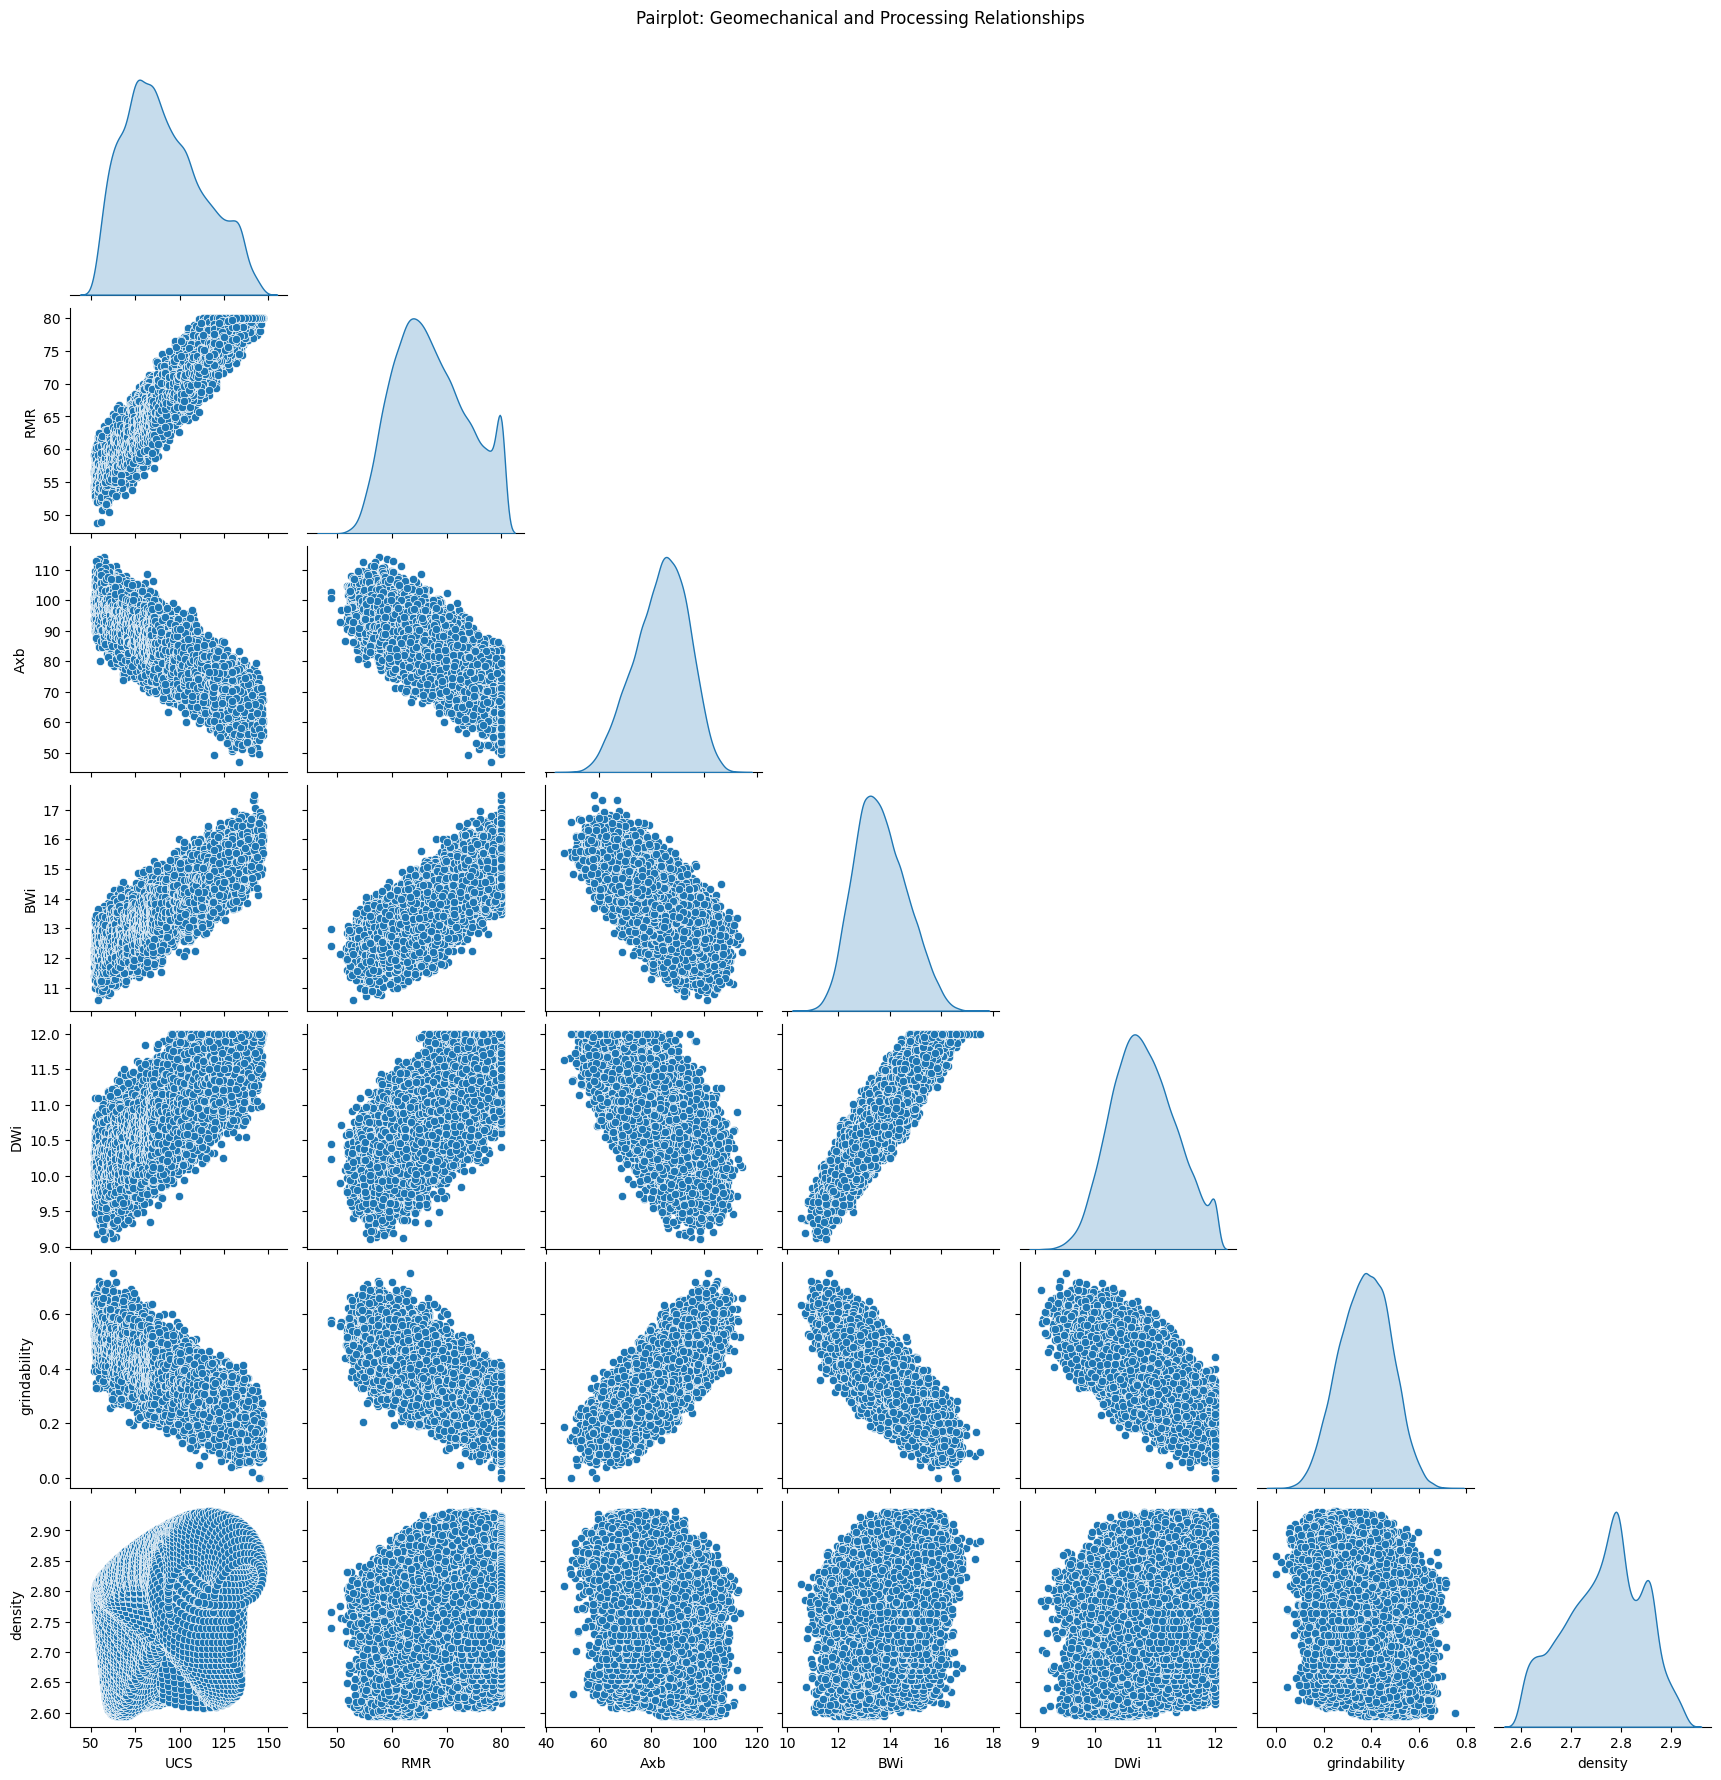

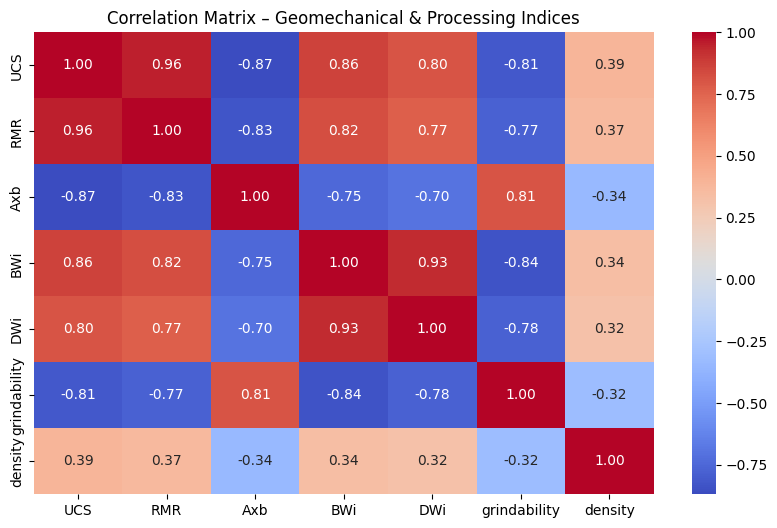

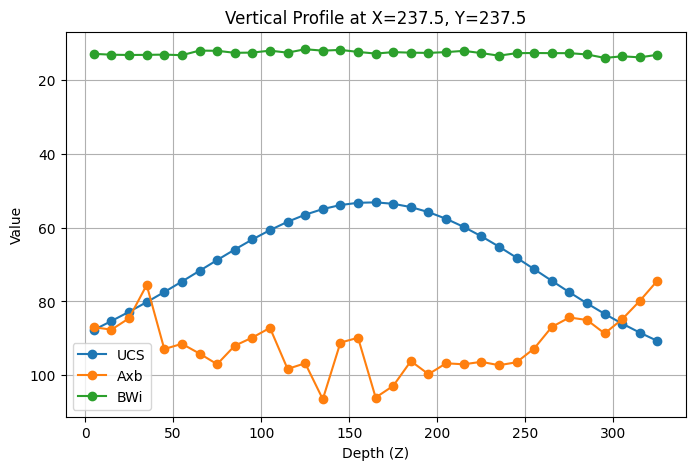

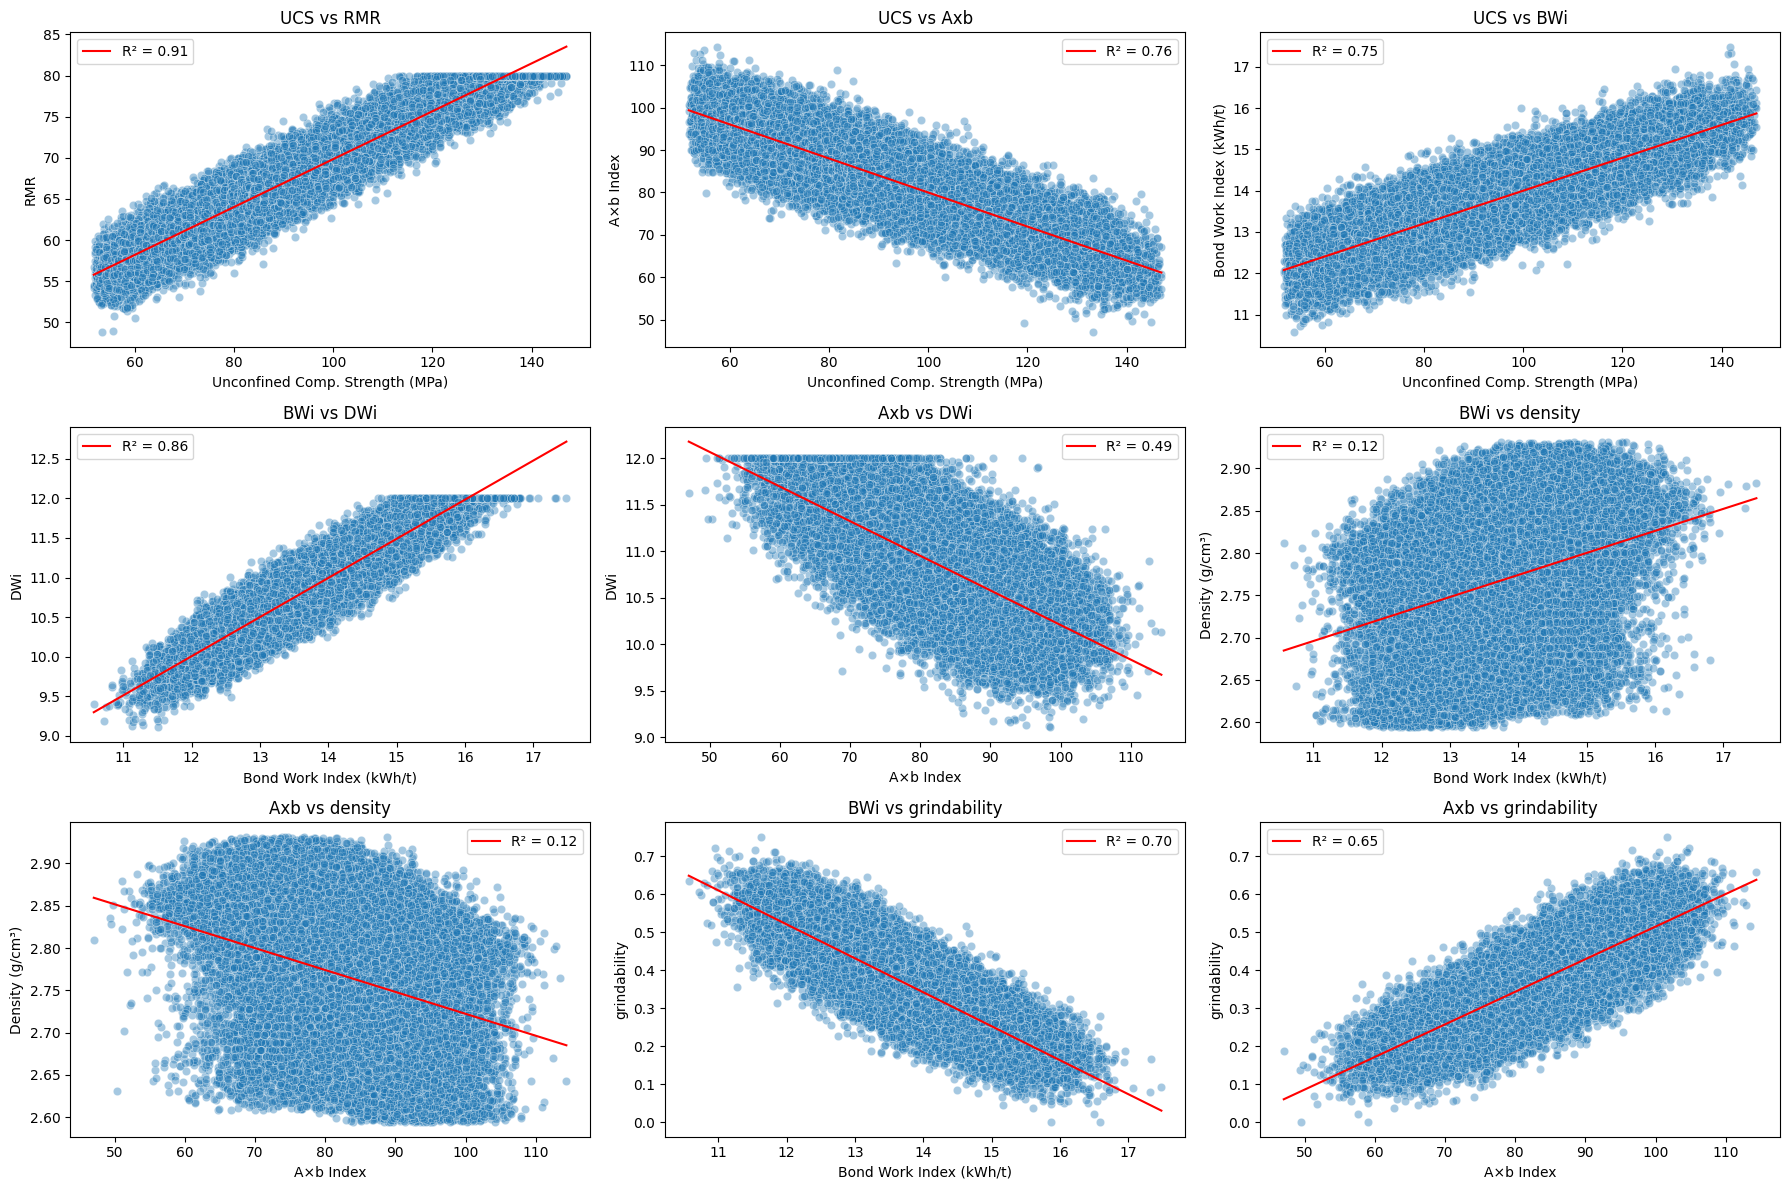

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --- 1. Pairplot matrix for dependency exploration ---

# Properties of interest for correlation and dependency inspection
pairplot_cols = ["UCS", "RMR", "Axb", "BWi", "DWi", "grindability", "density"]
df_subset = block_model_df[pairplot_cols].dropna()

sns.pairplot(df_subset, corner=True, diag_kind="kde")
plt.suptitle("Pairplot: Geomechanical and Processing Relationships", y=1.02)
plt.show()

# --- 2. Correlation heatmap (numeric only) ---
corr = df_subset.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix – Geomechanical & Processing Indices")
plt.show()

# --- 3. Vertical continuity check at a fixed X,Y position ---

# Find nearest XY slice for diagnostic vertical section
x_target = block_model_df["x"].unique()[np.abs(block_model_df["x"].unique() - 250).argmin()]
y_target = block_model_df["y"].unique()[np.abs(block_model_df["y"].unique() - 250).argmin()]

# Select all blocks along this vertical column
profile_df = block_model_df[
	np.isclose(block_model_df["x"], x_target) & np.isclose(block_model_df["y"], y_target)
]

if profile_df.empty:
	print(f"No blocks found at X={x_target:.1f}, Y={y_target:.1f}")

# Plot vertical profiles for key properties
plt.figure(figsize=(8, 5))
for prop in ["UCS", "Axb", "BWi"]:
	if prop in profile_df.columns:
		plt.plot(profile_df["z"], profile_df[prop], label=prop, marker='o')

plt.gca().invert_yaxis()
plt.xlabel("Depth (Z)")
plt.ylabel("Value")
plt.title(f"Vertical Profile at X={x_target:.1f}, Y={y_target:.1f}")
plt.legend()
plt.grid(True)
plt.show()

# --- 4. Crossplots with trendlines for dependency validation ---

cross_plot_pairs = [
	("UCS", "RMR"),
	("UCS", "Axb"),
	("UCS", "BWi"),
	("BWi", "DWi"),
	("Axb", "DWi"),
	("BWi", "density"),
	("Axb", "density"),
	("BWi", "grindability"),
	("Axb", "grindability")
]

# Layout settings for subplot grid
n_cols = 3
n_rows = int(np.ceil(len(cross_plot_pairs) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

# Generate scatterplots with linear regression overlays
for idx, (x, y) in enumerate(cross_plot_pairs):
	ax = axes[idx]
	df_plot = block_model_df[[x, y]].dropna()

	if df_plot.empty:
		ax.set_title(f"No data for {x} vs {y}")
		continue

	sns.scatterplot(data=df_plot, x=x, y=y, alpha=0.4, ax=ax)

	# Add linear trendline with R² annotation
	slope, intercept, r_value, p_value, _ = linregress(df_plot[x], df_plot[y])
	x_vals = np.linspace(df_plot[x].min(), df_plot[x].max(), 100)
	y_vals = slope * x_vals + intercept
	ax.plot(x_vals, y_vals, color="red", label=f"R² = {r_value**2:.2f}")

	ax.set_title(f"{x} vs {y}")
	ax.set_xlabel(property_labels.get(x, x))
	ax.set_ylabel(property_labels.get(y, y))
	ax.legend()

# Remove any unused subplots if total plots < grid size
for i in range(len(cross_plot_pairs), len(axes)):
	fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


### STEP 3: BLOCK MODEL VISUALISATION

This step provides multiple visualisation modes to inspect the synthetic block model. These views help verify spatial continuity, domain structure, and property distribution across the model’s geometry.

---

#### 🖼️ 3.1: Static Visualisation

- **Horizontal Slices (Z-level)** – Top-down views at user-selected depths
- **Vertical Sections (Y or X)** – Cross-sections through the model (default is Y)
- **3D Scatter Plot** – Interactive 3D view using Plotly for spatial inspection

Each visualisation is dynamically linked to the selected `primary_mineral`, and uses appropriate colourmaps and axis scaling.

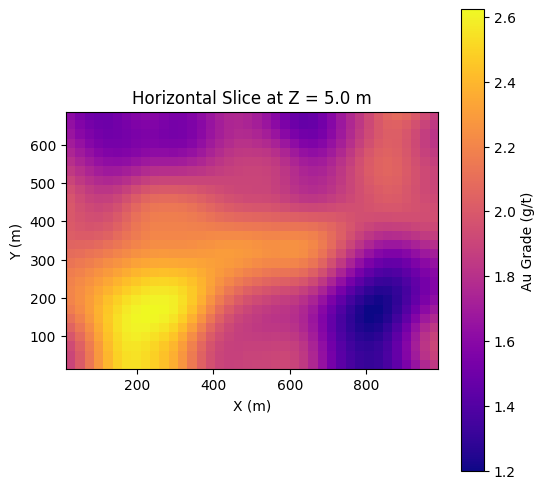

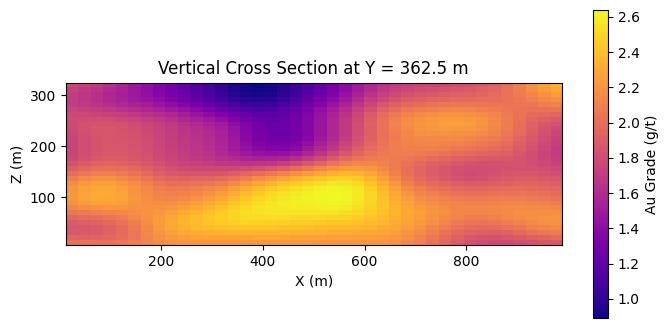

In [92]:
### STEP 3.1: STATIC & INTERACTIVE BLOCK MODEL VIEWS ###

import matplotlib.pyplot as plt
import plotly.express as px

# --- Horizontal Slice Viewer (Z-Level) ---

# Choose Z level to slice (typically near surface)
z_slice_value = block_model_df['z'].unique()[0]  # Modify index to choose other levels

# Filter block model to that Z level
slice_df = block_model_df[block_model_df['z'] == z_slice_value]

# Pivot to 2D matrix (Y vs X) for imshow
pivot = slice_df.pivot(index='y', columns='x', values=primary_mineral)
cmap = property_colormaps.get(primary_mineral, 'plasma')

# Plot horizontal slice
plt.figure(figsize=(6, 6))
plt.imshow(pivot.values, origin='lower', cmap=cmap,
		   extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()])
plt.title(f"Horizontal Slice at Z = {z_slice_value} m")
plt.colorbar(label=property_labels.get(primary_mineral, primary_mineral))
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.grid(False)
plt.show()

# --- Vertical Cross Section Viewer (Y-Level) ---

# Choose a Y value for cross-section (middle of model by default)
y_section_value = block_model_df['y'].unique()[len(block_model_df['y'].unique()) // 2]

# Filter to cross-section at this Y
section_df = block_model_df[block_model_df['y'] == y_section_value]

# Pivot to 2D matrix (Z vs X)
pivot = section_df.pivot(index='z', columns='x', values=primary_mineral)

# Plot vertical cross-section
plt.figure(figsize=(8, 4))
plt.imshow(pivot.values, origin='lower', cmap=cmap,
		   extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()])
plt.title(f"Vertical Cross Section at Y = {y_section_value} m")
plt.colorbar(label=property_labels.get(primary_mineral, primary_mineral))
plt.xlabel('X (m)')
plt.ylabel('Z (m)')
plt.grid(False)
plt.show()

# --- 3D Scatter Plot using Plotly ---

# Sample 20% for performance (optional)
sample_df = block_model_df.sample(frac=0.2, random_state=1)

fig = px.scatter_3d(sample_df,
					x='x', y='y', z='z',
					color=primary_mineral,
					color_continuous_scale=cmap,
					labels={primary_mineral: property_labels.get(primary_mineral, primary_mineral)},
					opacity=0.6,
					size_max=2,
					title=f'3D Block Model – {property_labels.get(primary_mineral, primary_mineral)}')

fig.update_layout(
	scene=dict(
		xaxis_title='X (m)',
		yaxis_title='Y (m)',
		zaxis_title='Z (m)'
	),
	margin=dict(l=0, r=0, b=0, t=30)
)
fig.show()

#### 🎞️ 3.2: Animated Depth Slices

Scroll through Z-level slices to simulate moving **downward through the deposit**. This animation helps visualise how mineral grades (or other properties) vary with depth and provides a dynamic overview of spatial continuity.

---

- Automatically steps through all Z levels using `primary_mineral` as the visualised property
- Useful for detecting vertical patterns, layering, or abrupt transitions
- Colour scale is fixed to allow consistent comparison between frames

In [93]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# --- Prepare Z-levels and figure setup ---

z_levels = sorted(block_model_df['z'].unique())

# Set colour scale range (can be adapted to other minerals)
vmin, vmax = 0, 3.5  # Use fixed range for visual consistency across frames

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 6))
img = ax.imshow(np.zeros((ny, nx)), cmap=cmap, origin='lower',
				extent=[0, extent[0], 0, extent[1]],
				vmin=vmin, vmax=vmax)

cbar = plt.colorbar(img, ax=ax)
cbar.set_label(property_labels.get(primary_mineral, primary_mineral))

# --- Define frame update logic ---

def update(frame):
	z_val = z_levels[frame]
	slice_df = block_model_df[block_model_df['z'] == z_val]

	# Pivot to grid and handle empty/missing cells
	pivot = slice_df.pivot(index='y', columns='x', values=primary_mineral)
	pivot = pivot.sort_index(ascending=True).sort_index(axis=1, ascending=True).fillna(0)

	img.set_data(pivot.values)
	ax.set_title(f"{property_labels.get(primary_mineral, primary_mineral)} – Z = {z_val} m")
	return [img]

# --- Animate ---

ani = animation.FuncAnimation(fig, update, frames=len(z_levels), interval=500)

# Don't show static plot frame
plt.close()

# Display animation inline (as JS)
HTML(ani.to_jshtml())


#### 🧭 3.3: Interactive Property Viewer

Use dropdown menus to explore different properties (e.g. `Au_grade`, `Cu_grade`, `density`) at specific Z levels. This widget-based viewer allows quick inspection of vertical slice data across all available variables.

---

- Built using `ipywidgets` for interactivity within Jupyter
- Supports any numerical property included in the block model
- Auto-detects colourmaps and labels based on user configuration

In [94]:
import ipywidgets as widgets
from IPython.display import display

# --- Define dropdown widgets ---

# Property selector (exclude spatial coordinates)
property_dropdown = widgets.Dropdown(
	options=[col for col in block_model_df.columns if col not in ['x', 'y', 'z']],
	value=primary_mineral,
	description='Property:'
)

# Z-level selector (sorted depth slices)
z_dropdown = widgets.Dropdown(
	options=sorted(block_model_df['z'].unique()),
	value=block_model_df['z'].unique()[0],
	description='Z Slice:'
)

# --- Interactive slice plotting function ---

def plot_interactive_slice(property_name, z_val):
	if property_name not in block_model_df.columns:
		print(f"⚠️ Property '{property_name}' not found in block model.")
		return

	# Subset data at selected Z level
	slice_df = block_model_df[block_model_df['z'] == z_val]

	# Pivot to 2D matrix (Y vs X) for plotting
	pivot = slice_df.pivot(index='y', columns='x', values=property_name)
	cmap = property_colormaps.get(property_name, 'plasma')
	label = property_labels.get(property_name, property_name)

	# Plot the selected slice
	plt.figure(figsize=(6, 6))
	plt.imshow(pivot.values, cmap=cmap, origin='lower',
			   extent=[pivot.columns.min(), pivot.columns.max(),
					   pivot.index.min(), pivot.index.max()])
	plt.title(f"{label} at Z = {z_val} m")
	plt.colorbar(label=label)
	plt.xlabel('X (m)')
	plt.ylabel('Y (m)')
	plt.grid(False)
	plt.show()

# --- Activate interactive viewer ---
widgets.interact(plot_interactive_slice, property_name=property_dropdown, z_val=z_dropdown);

interactive(children=(Dropdown(description='Property:', options=('Au_grade', 'Cu_grade', 'density', 'mag_sus',…

#### 🪪 3.4: Vertical Section Viewer

This interactive tool allows you to view vertical cross-sections through the block model in either the `X` or `Y` direction. Use the dropdowns and slider to control the section orientation, position, and property to visualise.

---

- **Choose section direction**: Slice along `Y` (default) or `X`
- **Adjust position**: Use the slider to move across the selected axis
- **Select property**: Any numeric block model variable (e.g. grade, density, UCS)
- Helps identify vertical features such as zonation, layering, or cut-off transitions

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import warnings

# --- Dropdowns for property and orientation ---
property_dropdown = widgets.Dropdown(
	options=[col for col in block_model_df.columns if col not in ['x', 'y', 'z']],
	value=primary_mineral,
	description='Property:'
)

orientation_dropdown = widgets.Dropdown(
	options=['Y', 'X'],
	value='Y',
	description='Section Dir:'
)

# --- Slider generator based on orientation ---
def update_slider_range(orientation):
	if orientation == 'Y':
		return widgets.FloatSlider(
			min=block_model_df['y'].min(),
			max=block_model_df['y'].max(),
			step=model_dimensions['block_size'][1],
			value=block_model_df['y'].mean(),
			description="Y Pos:"
		)
	else:
		return widgets.FloatSlider(
			min=block_model_df['x'].min(),
			max=block_model_df['x'].max(),
			step=model_dimensions['block_size'][0],
			value=block_model_df['x'].mean(),
			description="X Pos:"
		)

# Pre-run slider once to suppress warnings in some notebooks
with warnings.catch_warnings():
	warnings.simplefilter("ignore")
	update_slider_range(orientation_dropdown.value)

# --- Full vertical section viewer ---
def vertical_section_viewer(property_name, orientation):
	pos_slider = update_slider_range(orientation)
	cmap = property_colormaps.get(property_name, 'plasma')
	label = property_labels.get(property_name, property_name)

	def plot_section(pos_val):
		# Filter for slice in chosen direction
		if orientation == 'Y':
			section_df = block_model_df[np.isclose(block_model_df['y'], pos_val)]
			pivot = section_df.pivot(index='z', columns='x', values=property_name)
			xlabel = 'X (m)'
		else:
			section_df = block_model_df[np.isclose(block_model_df['x'], pos_val)]
			pivot = section_df.pivot(index='z', columns='y', values=property_name)
			xlabel = 'Y (m)'

		# Prepare grid and handle missing values
		pivot = pivot.sort_index().sort_index(axis=1).fillna(0)

		if pivot.empty:
			print(f"⚠️ No data available at {orientation} = {pos_val:.2f}")
			return

		# Plot vertical section
		plt.figure(figsize=(8, 4))
		plt.imshow(pivot.values, cmap=cmap, origin='lower',
				   extent=[pivot.columns.min(), pivot.columns.max(),
						   pivot.index.min(), pivot.index.max()])
		plt.colorbar(label=label)
		plt.title(f"{label} – Vertical Section at {orientation} = {pos_val:.2f} m")
		plt.xlabel(xlabel)
		plt.ylabel("Z (m)")
		plt.grid(False)
		plt.show()

	return widgets.interact(plot_section, pos_val=pos_slider)

# --- Launch viewer UI ---
vertical_section_viewer(property_name=property_dropdown.value, orientation=orientation_dropdown.value)


interactive(children=(FloatSlider(value=350.0, description='Y Pos:', max=687.5, min=12.5, step=25.0), Output()…

<function __main__.vertical_section_viewer.<locals>.plot_section(pos_val)>

#### 🔮 3.5: Future Enhancements

Planned features to expand spatial and geological context within visualisations:

- **Domain overlays** – Outline geological or economic domains on slice views for better interpretation
- **Domain filters or zoom tools** – Focus plots on specific areas (e.g. Orebody, Core)
- **Multi-property comparisons** – Show differences between properties side-by-side (e.g. Cu vs Au)
- **SMU-resolution viewer** – Simulate selective mining unit (SMU) resolution vs block resolution

### STEP 4: EXPORT BLOCK MODEL TO FILE

By this stage, the synthetic block model contains:

- **Spatial coordinates** (`x`, `y`, `z`)
- **Mineral grades** (e.g. `Au`, `Cu`)
- **Geophysical, geomechanical, and processing data**
- **Domain assignments** (`Orebody`, `Core`, `Background`)
- **Value-based classification** (`Ore` vs `Waste`)

You can now export the block model for downstream use in:

- External software (e.g. Excel, Deswik, Vulcan, Power BI)
- Further geostatistical, economic, or scheduling analysis
- Data versioning or sharing across platforms

Three export formats are supported:

- **CSV** – General-purpose, human-readable
- **Parquet** – Efficient for large datasets, ideal for reimport into Pandas
- **JSON (line-delimited)** – Web/API-friendly for lightweight workflows

🗂️ Files will be saved to: `../data/`


In [96]:
import os

# --- Set export directory and filenames ---
export_path = "../data/"
filename_base = "synthetic_block_model"
os.makedirs(export_path, exist_ok=True)

# Define full paths
csv_path = os.path.join(export_path, f"{filename_base}.csv")
parquet_path = os.path.join(export_path, f"{filename_base}.parquet")
json_path = os.path.join(export_path, f"{filename_base}.json")

# --- Export block model in multiple formats ---

# CSV: Human-readable, good for Excel/GIS
block_model_df.to_csv(csv_path, index=False)

# Parquet: Efficient binary format for Pandas reimport
block_model_df.to_parquet(parquet_path, index=False)

# JSON (line-delimited): Lightweight, API-compatible
block_model_df.to_json(json_path, orient="records", lines=True)

# --- Confirm successful export ---
print("✅ Block model exported successfully:")
print(f"  • CSV:     {csv_path}")
print(f"  • Parquet: {parquet_path}")
print(f"  • JSON:    {json_path}")


✅ Block model exported successfully:
  • CSV:     ../data/synthetic_block_model.csv
  • Parquet: ../data/synthetic_block_model.parquet
  • JSON:    ../data/synthetic_block_model.json


### 🧾 STEP 5: ADD ECONOMICS TO THE BLOCK MODEL

We now calculate the **value per tonne** for each block using:

$$
\text{\color{Aquamarine} \text{Value per tonne}} = \sum_i \left( \text{Grade}_i \times \text{Recovery}_i \times \text{Price}_i \right)
$$

Each mineral is handled individually with appropriate units and recovery factors:

- Supports multiple commodities with different units (e.g. **gold** in oz, **copper** in %)  
- Automatically converts USD-based prices to the chosen target currency (e.g. AUD)
- Creates individual value columns per mineral:
	- `value_Au_per_tonne`
	- `value_Cu_per_tonne`
- Computes a total combined value as `value_per_tonne`

---

#### 💻 5.1: COMPUTE VALUE PER TONNE

For each block:
- Apply recovery and unit conversion logic per mineral
- Convert value to the specified target currency
- Sum individual mineral contributions to compute total economic value

In [98]:
# --- Unit conversion constants ---
OZ_TO_GRAMS = 31.1035    # 1 troy ounce = 31.1035 grams
LB_TO_KG = 0.453592       # 1 pound = 0.453592 kilograms

# Assign currency tag for tracking
block_model_df['currency'] = target_currency

# --- Compute value per tonne for each mineral ---
for mineral, econ in economic_data.items():
	grade_col = f"{mineral}_grade"
	value_col = f"value_{mineral}_per_tonne"

	# Skip if grade column is missing
	if grade_col not in block_model_df.columns:
		continue

	recovery = econ["recovery"]
	unit = econ["unit"]
	exchange = exchange_rates[target_currency]

	if unit == "oz":
		# Convert USD/oz → AUD/g
		price_per_g = (econ["price_per_oz_usd"] / OZ_TO_GRAMS) * exchange
		block_model_df[value_col] = block_model_df[grade_col] * recovery * price_per_g

	elif unit == "%":
		# Convert USD/lb → AUD/kg, then apply grade as % (kg/t)
		price_per_kg = (econ["price_per_lb_usd"] / LB_TO_KG) * exchange
		block_model_df[value_col] = block_model_df[grade_col] * recovery * price_per_kg * 10  # % → kg/t

	else:
		raise ValueError(f"❌ Unknown unit type for {mineral}: '{unit}'")

# --- Total value across all minerals ---
value_cols = [col for col in block_model_df.columns
			  if col.startswith("value_") and col.endswith("_per_tonne")]

block_model_df["value_per_tonne"] = block_model_df[value_cols].sum(axis=1)


### 🧭 5.2: VISUALISE BLOCK VALUE PER TONNE

Use the dropdown viewer to explore block-level economic values and compare them with underlying grade or physical properties.

---

✅ Common selections include:

- `value_per_tonne` – Total block value (across all minerals)
- `value_Au_per_tonne`, `value_Cu_per_tonne` – Individual mineral value
- `Au_grade`, `Cu_grade`, `density` – Inputs contributing to value

This tool helps visually validate how value is distributed across the deposit, and assess if the model reflects expected economic trends.

In [99]:
# --- Extend interactive viewer to include value columns ---

# Exclude spatial and metadata columns from dropdown
exclude_cols = ['x', 'y', 'z', 'currency']
value_cols = [col for col in block_model_df.columns if col not in exclude_cols]

# Update the existing dropdown to include economic columns
property_dropdown.options = value_cols

# Launch interactive viewer (same as 3.3)
widgets.interact(plot_interactive_slice,
				 property_name=property_dropdown,
				 z_val=z_dropdown)

interactive(children=(Dropdown(description='Property:', options=('Au_grade', 'Cu_grade', 'density', 'mag_sus',…

<function __main__.plot_interactive_slice(property_name, z_val)>

### 🪨 5.3: CLASSIFY BLOCKS – ORE VS WASTE

Apply a basic economic **cut-off** to classify blocks as either **Ore** or **Waste**, based on their value per tonne:

---

- Default cut-off: `150 AUD/t`  
- Adds a new column: `class` (values: `"Ore"` or `"Waste"`)
- Enables downstream filtering, mine planning logic, or visualisation
- Simple but powerful way to simulate early-stage resource classification

In [100]:
# --- Set ore/waste cut-off threshold (in target currency per tonne) ---
value_cutoff = 150  # AUD/t

# --- Classify each block as 'Ore' or 'Waste' ---
block_model_df['class'] = np.where(
	block_model_df['value_per_tonne'] >= value_cutoff,
	'Ore',
	'Waste'
)

# --- Display basic statistics for validation ---

# Value distribution
print("Value per tonne (summary):")
print(block_model_df['value_per_tonne'].describe())

# Ore vs Waste distribution
print("\nBlock classification counts:")
print(block_model_df['class'].value_counts())


Value per tonne (summary):
count    36960.000000
mean       325.628237
std         43.610175
min        194.408135
25%        295.728917
50%        329.504208
75%        357.940421
max        438.752886
Name: value_per_tonne, dtype: float64

Block classification counts:
class
Ore    36960
Name: count, dtype: int64


### 🎨 5.4: VISUALISE ORE VS WASTE CLASS

Use the interactive viewer to explore how blocks have been classified based on economic value.

---

- Visualise `class` (categorical: `"Ore"` or `"Waste"`)
- Colour-coded using `Set1` colormap for clear separation
- Automatically switches to continuous colormaps for numeric properties
- Helpful for validating cut-off logic and identifying spatial patterns

In [101]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Output area for clean rendering ---
plot_output = widgets.Output()
display(plot_output)

# --- Interactive slice viewer with support for categorical data ('class') ---

def plot_interactive_slice(property_name, z_val):
	with plot_output:
		clear_output(wait=True)

		if property_name not in block_model_df.columns:
			print(f"⚠️ Property '{property_name}' not found in block model.")
			return

		# Extract Z-level slice
		slice_df = block_model_df[block_model_df['z'] == z_val]
		pivot = slice_df.pivot(index='y', columns='x', values=property_name)
		cmap = property_colormaps.get(property_name, 'plasma')

		# Special handling for categorical class ('Ore' / 'Waste')
		if property_name == 'class':
			label_map = {'Waste': 0, 'Ore': 1}
			mapped_df = pivot.replace(label_map).fillna(-1).astype(int)
			data = mapped_df.values
			vmin, vmax = 0, 1
		else:
			data = pivot.values
			vmin, vmax = property_display_ranges.get(property_name, (None, None))

		# Plot slice
		plt.figure(figsize=(6, 6))
		img = plt.imshow(data, cmap=cmap, origin='lower',
						 extent=[pivot.columns.min(), pivot.columns.max(),
								 pivot.index.min(), pivot.index.max()],
						 vmin=vmin, vmax=vmax)

		# Add colourbar
		if property_name == 'class':
			cbar = plt.colorbar(img)
			cbar.set_ticks([0, 1])
			cbar.set_ticklabels(['Waste', 'Ore'])
		else:
			plt.colorbar(img, label=property_labels.get(property_name, property_name))

		# Annotate and display
		plt.title(f"{property_labels.get(property_name, property_name)} at Z = {z_val} m")
		plt.xlabel("X (m)")
		plt.ylabel("Y (m)")
		plt.xlim(0, model_dimensions["extent"][0])
		plt.ylim(0, model_dimensions["extent"][1])
		plt.grid(False)
		plt.show()

# --- Activate interactive viewer ---
widgets.interact(
	plot_interactive_slice,
	property_name=property_dropdown,
	z_val=z_dropdown
)

Output()

interactive(children=(Dropdown(description='Property:', options=('Au_grade', 'Cu_grade', 'density', 'mag_sus',…

<function __main__.plot_interactive_slice(property_name, z_val)>

### 🧱 STEP 6: GEOLOGICAL DOMAINS

Now that each block has an assigned value and classification, we’ll add **geological domains** to provide spatial structure. These domains simulate realistic orebody geometry — useful for filtering, reporting, and later-stage scheduling or visualisation.

---

#### 🧭 Why Use Domains?

- Visually **highlight geologically significant regions** (e.g. core vs halo)
- Enable **selective filtering** (e.g. value within the Core only)
- Support spatial logic in **Mine-to-Mill optimisation or scheduling**

---

#### 📐 Step 6.1: Define Domain Geometry

We simulate three simple geological regions:

- **Orebody**: A cylindrical zone (e.g. vertical ore shoot)
- **Core**: A high-grade ellipsoid within the orebody
- **Background**: Everything outside defined domains

Each block is tagged using its `(x, y, z)` coordinates and the domain definitions. These tags can be used to:

- Overlay domain boundaries on 2D/3D plots  
- Filter block subsets by domain  
- Generate domain-specific summaries or statistics

In [102]:
# --- Domain inclusion logic based on block coordinates ---

def is_in_domain(row, params):
	shape = params["shape"]
	cx, cy = params["center"]
	z_min, z_max = params["depth_range"]

	dx = row["x"] - cx
	dy = row["y"] - cy
	z = row["z"]

	# Check vertical extent
	if not (z_min <= z <= z_max):
		return False

	# --- Cylindrical domain ---
	if shape == "cylinder":
		radius = params["radius"]
		return np.sqrt(dx**2 + dy**2) <= radius

	# --- Ellipsoidal domain ---
	elif shape == "ellipsoid":
		a, b, c = params["semi_axes"]
		dz_norm = (z - z_min) / (z_max - z_min)  # Normalised Z
		return (dx/a)**2 + (dy/b)**2 + dz_norm**2 <= 1

	# --- Tabular (flat) domain ---
	elif shape == "tabular":
		width_x = params.get("width_x", 100)
		return abs(dx) <= width_x / 2

	return False  # Unknown shape

# --- Apply domain definitions to the full DataFrame ---

def assign_domains(df, domain_defs):
	domain_flags = []

	for _, row in df.iterrows():
		label = "Background"  # Default if no domain match
		for name, params in domain_defs.items():
			if is_in_domain(row, params):
				label = name
		domain_flags.append(label)

	df["domain"] = domain_flags
	return df

# --- Tag each block with a geological domain ---
block_model_df = assign_domains(block_model_df, domain_definitions)

# --- Summary output ---
print("\nDomain counts:")
print(block_model_df['domain'].value_counts())



Domain counts:
domain
Background    36648
Orebody         280
Core             32
Name: count, dtype: int64


### 📊 6.2: SUMMARY STATISTICS BY DOMAIN

Generate summary statistics for each geological domain to compare their economic and geological characteristics:

---

**Included metrics:**

- **Value per tonne** – Mean, standard deviation, min, max  
- **Gold and copper grades** – Mean and standard deviation  
- **Ore block count** – Number of blocks classified as `"Ore"`  
- **Ore percentage** – Share of ore blocks in each domain  
- **Total blocks** – Volume proxy for domain size

This allows validation of spatial modelling realism and domain-based economic potential.


In [103]:
import pandas as pd
from IPython.display import display

# --- Compute summary statistics grouped by domain ---

domain_summary = block_model_df.groupby('domain').agg({
	'value_per_tonne': ['mean', 'std', 'min', 'max'],
	'Au_grade': ['mean', 'std'],
	'Cu_grade': ['mean', 'std'],
	'class': lambda x: (x == 'Ore').sum(),  # Count of ore blocks
})

# --- Flatten multi-level column names ---
domain_summary.columns = ['_'.join(col).strip() for col in domain_summary.columns.values]

# --- Rename classification column ---
domain_summary.rename(columns={'class_<lambda>': 'ore_block_count'}, inplace=True)

# --- Add total block count per domain ---
domain_summary['total_blocks'] = block_model_df.groupby('domain').size()

# --- Calculate percentage of ore blocks in each domain ---
domain_summary['ore_percentage'] = (
	100 * domain_summary['ore_block_count'] / domain_summary['total_blocks']
)

# --- Round for readability ---
domain_summary = domain_summary.round(2)

# --- Sort domains by average value per tonne ---
domain_summary = domain_summary.sort_values('value_per_tonne_mean', ascending=False)

display(domain_summary)

,value_per_tonne_mean,value_per_tonne_std,value_per_tonne_min,value_per_tonne_max,Au_grade_mean,Au_grade_std,Cu_grade_mean,Cu_grade_std,ore_block_count,total_blocks,ore_percentage
domain,,,,,,,,,,,
Core,371.92,5.86,355.72,382.56,2.44,0.05,0.59,0.02,32,32,100.0
Orebody,364.91,15.67,321.89,393.67,2.39,0.14,0.58,0.03,280,280,100.0
Background,325.29,43.62,194.41,438.75,1.90,0.35,0.68,0.08,36648,36648,100.0


#### 🎛️ 6.3: INTERACTIVE DOMAIN VIEWER

Enhance the interactive slice viewer with **domain-aware controls**:

---

✅ Features:

- **Dropdown** to filter by domain: `Orebody`, `Core`, `Background`, or `All`
- **Zoom toggle** to focus the view on the selected domain
- **Overlay toggle** to outline domain shapes on the plot
- Works with both **numeric** properties (e.g. `Au_grade`) and **categorical** ones (e.g. `class`)

---

🔍 Use this viewer to:

- Compare grades and values across domains
- Verify geometric extents and continuity of zones
- Visually confirm the impact of economic cut-offs within geological structures

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# --- Output container for dynamic rendering ---
output_plot = widgets.Output()

# --- UI Controls ---
domain_options = ['All'] + list(domain_definitions.keys()) + ['Background']

property_dropdown = widgets.Dropdown(
	options=[col for col in block_model_df.columns if col not in ['x', 'y', 'z', 'domain']],
	value='value_per_tonne',
	description='Property:'
)

z_dropdown = widgets.Dropdown(
	options=sorted(block_model_df['z'].unique()),
	value=block_model_df['z'].min(),
	description='Z Slice:'
)

domain_dropdown = widgets.Dropdown(
	options=domain_options,
	value='All',
	description='Domain:'
)

zoom_checkbox = widgets.Checkbox(
	value=False,
	description='Zoom to Domain',
	indent=False
)

overlay_checkbox = widgets.Checkbox(
	value=False,
	description='Show Domain Outline',
	indent=False
)

# --- Main plotting function ---
def plot_interactive_slice(property_name, z_val, selected_domain, zoom_to_domain, show_outline):
	with output_plot:
		clear_output(wait=True)

		if property_name not in block_model_df.columns:
			print(f"⚠️ Property '{property_name}' not found in block model.")
			return

		# Filter by domain
		df = block_model_df
		if selected_domain != 'All':
			df = df[df['domain'] == selected_domain]

		# Filter by Z level
		slice_df = df[df['z'] == z_val]
		if slice_df.empty:
			print(f"⚠️ No blocks found for domain '{selected_domain}' at Z = {z_val} m.")
			return

		# Pivot slice for plotting
		pivot = slice_df.pivot(index='y', columns='x', values=property_name)
		cmap = property_colormaps.get(property_name, 'plasma')

		# Handle class (categorical)
		if property_name == 'class':
			label_map = {'Waste': 0, 'Ore': 1}
			mapped_df = pivot.replace(label_map).fillna(-1).astype(int)
			data = mapped_df.values
			vmin, vmax = 0, 1
		else:
			data = pivot.values
			vmin, vmax = property_display_ranges.get(property_name, (None, None))

		# Plot
		fig, ax = plt.subplots(figsize=(6, 6))
		img = ax.imshow(data, cmap=cmap, origin='lower',
						extent=[pivot.columns.min(), pivot.columns.max(),
								pivot.index.min(), pivot.index.max()],
						vmin=vmin, vmax=vmax)

		# Optional: Overlay domain outlines (if 'All' is selected)
		if show_outline and selected_domain == 'All':
			domain_mask = block_model_df[block_model_df['z'] == z_val].pivot(index='y', columns='x', values='domain')
			for domain_name, colour in domain_colours.items():
				mask = domain_mask == domain_name
				if mask.any().any():
					ax.contour(mask.astype(int).values, levels=[0.5], colors=[colour], linewidths=1.5,
							   extent=[mask.columns.min(), mask.columns.max(),
									   mask.index.min(), mask.index.max()])

		# Colourbar
		if property_name == 'class':
			cbar = plt.colorbar(img, ticks=[0.25, 0.75])
			cbar.ax.set_yticklabels(['Waste', 'Ore'])
		else:
			plt.colorbar(img, label=property_labels.get(property_name, property_name))

		# Labels and zoom logic
		ax.set_title(f"{property_labels.get(property_name, property_name)} at Z = {z_val} m | Domain: {selected_domain}")
		ax.set_xlabel("X (m)")
		ax.set_ylabel("Y (m)")

		if zoom_to_domain and selected_domain != 'All':
			ax.set_xlim(slice_df['x'].min(), slice_df['x'].max())
			ax.set_ylim(slice_df['y'].min(), slice_df['y'].max())
		else:
			ax.set_xlim(0, model_dimensions["extent"][0])
			ax.set_ylim(0, model_dimensions["extent"][1])

		plt.grid(False)
		plt.show()

# --- Bind controls to output ---
controls = widgets.VBox([
	property_dropdown,
	z_dropdown,
	domain_dropdown,
	zoom_checkbox,
	overlay_checkbox
])

interactive_plot = widgets.interactive_output(
	plot_interactive_slice,
	{
		'property_name': property_dropdown,
		'z_val': z_dropdown,
		'selected_domain': domain_dropdown,
		'zoom_to_domain': zoom_checkbox,
		'show_outline': overlay_checkbox
	}
)

# --- Display UI ---
display(widgets.VBox([controls, output_plot]))


#### 📚 6.4: VERTICAL DOMAIN VIEWER

Inspect vertical sections through the block model with domain-aware filtering and flexible orientation.

---

✅ Features:
- Choose between **X** or **Y** directional sections
- Filter to specific domains (e.g. `Orebody`, `Core`, `Background`)
- View properties such as `Au_grade`, `value_per_tonne`, or `class`
- Colour scales and categorical labels handled automatically
- Dynamic slider to move through section positions

This tool helps validate geometry, assess zonation, and inspect classification performance within vertical slices.

In [105]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Output container ---
vertical_output = widgets.Output()

# --- Dropdowns for user controls ---
orientation_dropdown = widgets.Dropdown(
	options=['Y', 'X'],
	value='Y',
	description='Section Dir:'
)

section_property_dropdown = widgets.Dropdown(
	options=[col for col in block_model_df.columns if col not in ['x', 'y', 'z']],
	value='Au_grade',
	description='Property:'
)

domain_filter_dropdown = widgets.Dropdown(
	options=['All'] + list(domain_definitions.keys()) + ['Background'],
	value='All',
	description='Domain:'
)

# --- Main section update function ---
def update_section_viewer(property_name, orientation, selected_domain):
	with vertical_output:
		clear_output(wait=True)

		# Determine axis and available positions
		axis = 'y' if orientation == 'Y' else 'x'
		unique_vals = sorted(block_model_df[axis].unique())

		# Create position selector (dropdown for vertical plane)
		pos_slider = widgets.Dropdown(
			options=unique_vals,
			value=unique_vals[len(unique_vals)//2],
			description=f"{axis.upper()} Pos:"
		)

		def plot_section(pos_val):
			if property_name not in block_model_df.columns:
				print(f"⚠️ Property '{property_name}' not found in block model.")
				return

			df = block_model_df.copy()

			# Filter by domain if needed
			if selected_domain != 'All':
				df = df[df['domain'] == selected_domain]

			section_df = df[np.isclose(df[axis], pos_val)]

			if section_df.empty:
				print(f"⚠️ No blocks found in domain '{selected_domain}' at {axis.upper()} = {pos_val} m.")
				return

			# Determine plot axes
			index_axis = 'z'
			column_axis = 'x' if axis == 'y' else 'y'
			pivot = section_df.pivot(index=index_axis, columns=column_axis, values=property_name)

			cmap = property_colormaps.get(property_name, 'plasma')
			label_map = {'Waste': 0, 'Ore': 1}

			# Handle categorical display (e.g. class)
			if property_name == 'class':
				for col in pivot.columns:
					pivot[col] = pivot[col].map(label_map).fillna(-1).astype(int)
				vmin, vmax = 0, 1
			else:
				vmin, vmax = property_display_ranges.get(property_name, (None, None))

			# Plot the vertical section
			plt.figure(figsize=(8, 4))
			img = plt.imshow(pivot.values, cmap=cmap, origin='lower',
							 extent=[pivot.columns.min(), pivot.columns.max(),
									 pivot.index.min(), pivot.index.max()],
							 vmin=vmin, vmax=vmax)

			# Add colourbar with labels
			if property_name == 'class':
				cbar = plt.colorbar(img, ticks=[0.25, 0.75])
				cbar.ax.set_yticklabels(['Waste', 'Ore'])
			else:
				plt.colorbar(img, label=property_labels.get(property_name, property_name))

			# Plot metadata
			plt.title(f"{property_labels.get(property_name, property_name)} at {axis.upper()} = {pos_val} m | Domain: {selected_domain}")
			plt.xlabel(f"{column_axis.upper()} (m)")
			plt.ylabel("Z (m)")
			plt.xlim(0, model_dimensions["extent"][0])
			plt.ylim(0, model_dimensions["extent"][2])
			plt.grid(False)
			plt.show()

		# Display the slider and link to plot function
		display(widgets.interact(plot_section, pos_val=pos_slider))

# --- Display user interface ---
display(widgets.VBox([
	section_property_dropdown,
	orientation_dropdown,
	domain_filter_dropdown
]))

# --- Connect controls to plotting function ---
widgets.interactive_output(
	update_section_viewer,
	{
		'property_name': section_property_dropdown,
		'orientation': orientation_dropdown,
		'selected_domain': domain_filter_dropdown
	}
)

display(vertical_output)


Output()

#### 📊 6.5: DOMAIN SUMMARY STATISTICS

Generate descriptive statistics for each geological domain across key attributes.

---

✅ Default outputs include:
- Mean, standard deviation, min, max for:
	- `Au_grade`, `Cu_grade`
	- `density`
	- `value_per_tonne`
- Results grouped by `domain`

📌 *This can be extended later to include:*
- Volume-weighted averages
- Filtering by domain type or block class
- Export to CSV or Excel


In [106]:
import pandas as pd

# --- Set pandas display option (optional) ---
pd.set_option('display.max_rows', None)  # Show all rows in notebook output

# --- Compute descriptive stats grouped by domain ---
domain_summary = block_model_df.groupby("domain")[
	['Au_grade', 'Cu_grade', 'density', 'value_per_tonne']
].describe().round(2)

# --- Display the summary table ---
display(domain_summary)


Au_grade                                           Cu_grade        \
              count  mean   std   min   25%   50%   75%   max    count  mean   
domain                                                                         
Background  36648.0  1.90  0.35  0.86  1.65  1.94  2.16  2.75  36648.0  0.68   
Core           32.0  2.44  0.05  2.32  2.41  2.44  2.46  2.55     32.0  0.59   
Orebody       280.0  2.39  0.14  2.04  2.30  2.39  2.49  2.68    280.0  0.58   

            ... density       value_per_tonne                                 \
            ...     75%   max           count    mean    std     min     25%   
domain      ...                                                                
Background  ...    2.82  2.93         36648.0  325.29  43.62  194.41  295.38   
Core        ...    2.75  2.76            32.0  371.92   5.86  355.72  369.43   
Orebody     ...    2.76  2.79           280.0  364.91  15.67  321.89  355.22   

                                    
               50%     75%     max  
domain                              
Background  329.01  357.44  438.75  
Core        373.13  375.07  382.56  
Orebody     366.33  376.88  393.67  

[3 rows x 32 columns]

### 🟡 STEP 7: OPTIONAL ENHANCEMENTS

This section introduces optional features that add realism and utility to the synthetic block model. These enhancements are modular and can be implemented incrementally.

---

🔧 Potential Add-ons:
1. Volume and tonnage calculations per domain/class
2. Resource estimation (grade × tonnage)
3. Add unique block IDs for tracking and sampling
4. Introduce Selective Mining Unit (SMU) logic
5. 3D voxel visualisation using `pyvista` or `vedo`
6. Output validation with histograms or violin plots
7. Simulate random drillholes for comparison and sampling

These features increase the model's value for teaching, testing, or early-stage Mine-to-Mill and resource estimation workflows.


### 🧮 7.1: VOLUME AND TONNAGE CALCULATIONS

Each block has a fixed volume based on its dimensions. By multiplying this with block-level density, we can estimate:

- **Block volume** in cubic metres (`m³`)
- **Block mass** in metric tonnes
- **Aggregated tonnage** grouped by geological domain and Ore/Waste classification

This is a critical step toward resource estimation and production scheduling.


In [107]:
import pandas as pd
import IPython.display as disp

# --- Calculate block volume and mass ---
block_volume = (
	model_dimensions["block_size"][0] *
	model_dimensions["block_size"][1] *
	model_dimensions["block_size"][2]
)

# Assign volume and mass to each block
block_model_df["volume_m3"] = block_volume
block_model_df["tonnes"] = block_model_df["volume_m3"] * block_model_df["density"]

# --- Aggregate tonnage and volume by domain and classification ---
tonnage_summary = block_model_df.groupby(["domain", "class"])[
	["volume_m3", "tonnes"]
].sum().round(2)

# --- Display the summary ---
disp.display(tonnage_summary)


,,volume_m3,tonnes
domain,class,,
Background,Ore,229050000,6.332732e+08
Core,Ore,200000,5.472092e+05
Orebody,Ore,1750000,4.788868e+06


### 💰 7.2: RESOURCE ESTIMATION BY DOMAIN

Estimate contained metal by combining **grade** and **tonnage** for each block, grouped by geological domain and Ore/Waste class.

---

📐 Formula:
$$
\text{Contained Metal} = \sum(\text{Grade} \times \text{Tonnes})
$$

---

✅ Features:
- Aggregates **tonnes**, **average grade**, and **contained metal**
- Applies unit-aware conversion:
	- Gold (g/t × tonnes → oz)
	- Copper (% × tonnes → tonnes)
- Outputs results by `Domain` and `Class` for each `Mineral`


In [108]:
resource_table = []

# --- Loop through each mineral and domain/class combination ---
for mineral in minerals:
	grade_col = f"{mineral}_grade"

	for (domain, ore_class), group in block_model_df.groupby(["domain", "class"]):
		tonnes = group["tonnes"].sum()
		avg_grade = group[grade_col].mean()

		# --- Convert grade × tonnes into contained metal ---
		unit = economic_data[mineral]["unit"]

		if unit == "oz":
			# g/t × tonnes ÷ 31.1035 = ounces
			contained = (group[grade_col] * group["tonnes"] / 31.1035).sum()
		elif unit == "%":
			# % × tonnes ÷ 100 = tonnes of metal
			contained = (group[grade_col] * group["tonnes"] / 100).sum()
		else:
			contained = np.nan  # Unknown unit

		resource_table.append({
			"Mineral": mineral,
			"Domain": domain,
			"Class": ore_class,
			"Tonnes": round(tonnes, 2),
			"Avg Grade": round(avg_grade, 3),
			"Contained": round(contained, 2)
		})

# --- Convert to DataFrame and display ---
resource_df = pd.DataFrame(resource_table)
disp.display(resource_df)


,Mineral,Domain,Class,Tonnes,Avg Grade,Contained
0,Au,Background,Ore,6.332732e+08,1.902,38635442.66
1,Au,Core,Ore,5.472092e+05,2.436,42860.88
2,Au,Orebody,Ore,4.788868e+06,2.387,367411.97
3,Cu,Background,Ore,6.332732e+08,0.682,4317924.55
4,Cu,Core,Ore,5.472092e+05,0.586,3204.61
5,Cu,Orebody,Ore,4.788868e+06,0.577,27650.81


### 🆔 7.3: ASSIGN BLOCK IDs

Each block is given a **unique identifier** based on its spatial coordinates (`x`, `y`, `z`). This ensures traceability when:

- Sampling or drilling simulations
- Exporting to external systems (e.g. CSV, GIS, pit shells)
- Tracking blocks across processes or transformations

---

🧠 Format: `"x_y_z"` using the block’s centre coordinates

In [109]:
# --- Create unique block IDs using X, Y, Z centre coordinates ---
block_model_df["block_id"] = (
	block_model_df["x"].astype(int).astype(str) + "_" +
	block_model_df["y"].astype(int).astype(str) + "_" +
	block_model_df["z"].astype(int).astype(str)
)

# --- Preview first few blocks ---
block_model_df[["block_id", "x", "y", "z"]].head(3)


,block_id,x,y,z
0,12_12_5,12.5,12.5,5.0
1,37_12_5,37.5,12.5,5.0
2,62_12_5,62.5,12.5,5.0


### ⛏️ 7.4: SMU ADJUSTMENT

In real mining operations, selectivity is limited by equipment size (e.g. excavator bucket width). The **Selective Mining Unit (SMU)** defines the smallest unit of material that can be mined separately.

---

This step applies a simplified SMU logic by:
- Smoothing the `value_per_tonne` attribute using a 3D moving average
- Reclassifying blocks as Ore or Waste based on the **smoothed value**
- Storing the adjusted result as `value_smu` and `class_smu`

This simulates dilution, misclassification, and loss of selectivity in small-scale geological variability.

In [110]:
from scipy.ndimage import uniform_filter
import numpy as np

# --- Create 3D grid based on X, Y, Z shape ---
nx = int(model_dimensions["extent"][0] / model_dimensions["block_size"][0])
ny = int(model_dimensions["extent"][1] / model_dimensions["block_size"][1])
nz = int(model_dimensions["extent"][2] / model_dimensions["block_size"][2])

# --- Reshape value_per_tonne into 3D array ---
value_array = block_model_df["value_per_tonne"].values.reshape((nz, ny, nx))  # Z, Y, X

# --- Apply 3D uniform filter (e.g. SMU = 3×3×1) ---
smoothed_array = uniform_filter(value_array, size=(1, 3, 3))  # Only smooth in XY plane

# --- Flatten and assign to DataFrame ---
block_model_df["value_smu"] = smoothed_array.flatten()

# --- Classify based on smoothed value ---
block_model_df["class_smu"] = np.where(
	block_model_df["value_smu"] >= value_cutoff, "Ore", "Waste"
)

### 🧊 7.5: 3D BLOCK MODEL VISUALISATION (WITH PYVISTA)

This tool visualises the synthetic block model in 3D using PyVista, with two different rendering styles:

---

#### 1️⃣ Point Cloud View
- Displays each block as a sphere at its (x, y, z) centre
- Useful for visualising scatter-like distributions or categories (e.g. class, lithology)
- Lightweight and fast, suitable for large block models

---

#### 2️⃣ Voxel Grid View
- True volumetric rendering using `ImageData` (blocks shown as solid voxels)
- Preserves spatial resolution and block dimensions
- Supports **opacity maps** to reveal internal structures

---

#### 3️⃣ Voxel Slice View
- Cross-sectional slices through X, Y, and Z axes
- Ideal for inspecting vertical or horizontal transitions in grade, value, or classification

---

✅ All views include:
- Dropdown for selecting visualised property (e.g., `Au_grade`, `value_per_tonne`)
- Interactive sliders for slice control
- Configurable opacity mapping (`linear`, `sigmoid`, etc.)

📌 Useful for presentations, spatial QA/QC, and domain verification

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pyvista as pv

# --- Compute global colour scale range (shared by both plots) ---
def get_color_range(property_col):
    return (
        block_model_df[property_col].min(),
        block_model_df[property_col].max()
    )

###--- POINT CLOUD RENDERING ---###
def plot_voxels_point_cloud(property_col="value_per_tonne"):
	"""Render block model as 3D point cloud (scatter spheres)"""
	if property_col not in block_model_df.columns:
		print(f"⚠️ Property '{property_col}' not found.")
		return

	coords = block_model_df[["x", "y", "z"]].values
	values = block_model_df[property_col].values
	cloud = pv.PolyData(coords)
	cloud[property_col] = values

	pv.plot(
		cloud,
		scalars=property_col,
		point_size=5,
		render_points_as_spheres=True,
		cmap=property_colormaps.get(property_col, "plasma"),
		clim=get_color_range(property_col),
		show_scalar_bar=True,
		notebook=True,
		jupyter_backend='static'
	)

###--- VOXEL GRID OR SLICE ---###    
def plot_voxel_grid(property_col="value_per_tonne", use_slice=False, opacity_map="linear",
					x_val=None, y_val=None, z_val=None):
	"""Render block model as voxel grid or orthogonal slice using ImageData"""
	if property_col not in block_model_df.columns:
		print(f"⚠️ Property '{property_col}' not found.")
		return
	
	# Geometry setup
	dx, dy, dz = model_dimensions["block_size"]
	x0, y0, z0 = model_dimensions["origin"]
	nx = int(model_dimensions["extent"][0] / dx)
	ny = int(model_dimensions["extent"][1] / dy)
	nz = int(model_dimensions["extent"][2] / dz)

	# Build voxel grid
	grid = pv.ImageData(
		dimensions=(nx + 1, ny + 1, nz + 1),
		spacing=(dx, dy, dz),
		origin=(x0, y0, z0)
	)

	# Reshape scalar data into 3D grid (Z, Y, X order)
	try:
		data_3d = block_model_df[property_col].values.reshape((nz, ny, nx))
	except ValueError:
		print("⚠️ Reshape error. Property may be missing or model size changed.")
		return

	grid.cell_data[property_col] = data_3d.flatten(order="F")

	# Plot either full voxel volume or slice
	if use_slice:
		x_val = x_val if x_val is not None else extent[0] / 2
		y_val = y_val if y_val is not None else extent[1] / 2
		z_val = z_val if z_val is not None else extent[2] / 2

		sliced = grid.slice_orthogonal(x=x_val, y=y_val, z=z_val)
		pv.plot(
			sliced,
			scalars=property_col,
			cmap=property_colormaps.get(property_col, "plasma"),
			clim=get_color_range(property_col),
			show_scalar_bar=True,
			notebook=True,
			jupyter_backend='static'
		)
	else:
		pv.plot(
			grid,
			scalars=property_col,
			cmap=property_colormaps.get(property_col, "plasma"),
			opacity=opacity_map,
			clim=get_color_range(property_col),
			show_scalar_bar=True,
			notebook=True,
			jupyter_backend='static'
		)

###--- SLICE COORDINATE SLIDERS ---###
x_slider = widgets.IntSlider(
	description="X Slice:", min=0, max=model_dimensions['extent'][0], step=25, value=500
	)
y_slider = widgets.IntSlider(
	description="Y Slice:", min=0, max=model_dimensions['extent'][1], step=25, value=350
	)
z_slider = widgets.IntSlider(
	description="Z Slice:", min=0, max=model_dimensions['extent'][2], step=10, value=165
	)

###--- UI CONTROLS ---###
voxel_property_dropdown = widgets.Dropdown(
	options=[col for col in block_model_df.columns if col not in ['x', 'y', 'z', 'block_id', 'currency']],
	value="value_per_tonne",
	description="Property:"
)

view_type_radio = widgets.RadioButtons(
	options=["Point Cloud", "Voxel Grid", "Voxel Slice"],
	value="Voxel Grid",
	description="View Type:"
)

opacity_dropdown = widgets.Dropdown(
	options=["linear", "linear_r", "sigmoid", "sigmoid_5", "sigmoid_10", "geom", "geom_r"],
	value="linear",
	description="Opacity:"
)

###--- VIEW SELECTION HANDLER ---###
def interactive_voxel_plot(property_col, view_type, opacity, x_val, y_val, z_val):
	if view_type == "Point Cloud":
		plot_voxels_point_cloud(property_col)
	elif view_type == "Voxel Grid":
		plot_voxel_grid(property_col=property_col, use_slice=False, opacity_map=opacity)
	elif view_type == "Voxel Slice":
		plot_voxel_grid(property_col=property_col, use_slice=True, opacity_map=opacity,
						x_val=x_val, y_val=y_val, z_val=z_val)
	else:
		print("Unknown view type selected.")

###--- BIND INTERACTORS ---###
ui = widgets.VBox([
	voxel_property_dropdown,
	view_type_radio,
	opacity_dropdown,
	x_slider,
	y_slider,
	z_slider
])

interactive_out = widgets.interactive_output(
	interactive_voxel_plot,
	{
		"property_col": voxel_property_dropdown,
		"view_type": view_type_radio,
		"opacity": opacity_dropdown,
		"x_val": x_slider,
		"y_val": y_slider,
		"z_val": z_slider
	}
)

display(ui, interactive_out)



Output()

### 📊 7.6: DISTRIBUTION & CORRELATION CHECKS

Perform basic data validation to understand how properties behave across the model.

---

#### 📈 What’s Included:
- **Histograms** for key numeric properties (e.g. grades, value, UCS)
- **KDE overlays** for shape checking
- **Correlation matrix heatmap** to explore inter-parameter relationships

These checks are especially useful after applying dependency logic (e.g. UCS → RMR) to ensure that realistic trends and variability are preserved.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Histogram Plots ---
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
props_to_plot = ['Au_grade', 'Cu_grade', 'value_per_tonne', 'density', 'UCS', 'Axb', 'BWi', 'DWi', 'RMR']

for i, col in enumerate(props_to_plot):
    sns.histplot(block_model_df[col], kde=True, bins=30, ax=axes[i // 3, i % 3])
    axes[i // 3, i % 3].set_title(f"Distribution of {col}")
    axes[i // 3, i % 3].set_xlabel(col)
    axes[i // 3, i % 3].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# --- Correlation Matrix ---
numeric_df = block_model_df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Matrix of Numeric Properties")
plt.show()


### 🛠️ 7.7: INTERACTIVE DRILLHOLE ASSAY VIEWER

Simulate vertical drillhole assays through the block model and compare **grade trends** between selected metals.

---

#### 🎯 Features:
- **Randomly sampled drillholes** based on `(x, y)` grid positions
- Select a drillhole by `ID` and choose **two metals** to compare
- Plot shows grade (X-axis) vs depth (Y-axis, inverted)
- Auto-adjusts to avoid selecting the same metal twice

---

#### 🧪 Use Cases:
- Validate vertical grade continuity in the block model
- Visually assess co-enrichment of metals (e.g. `Au` vs `Cu`)
- Identify zonation patterns or abrupt changes in mineralisation

In [ ]:
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go

# --- Drillhole Generation Parameters ---
n_holes = drillhole_parameters["n_holes"]
np.random.seed(drillhole_parameters["random_seed"])

# --- Get unique X and Y coordinates ---
x_values = sorted(block_model_df["x"].unique())
y_values = sorted(block_model_df["y"].unique())

# --- Randomly sample drillhole positions ---
hole_coords = np.random.choice(len(x_values) * len(y_values), n_holes, replace=False)
sampled_holes = []

for idx in hole_coords:
    xi = x_values[idx % len(x_values)]
    yi = y_values[idx // len(x_values)]

    hole_df = block_model_df[
        (block_model_df["x"] == xi) & (block_model_df["y"] == yi)
    ].sort_values("z")

    hole_df = hole_df.copy()
    hole_df["hole_id"] = f"H{idx}"
    sampled_holes.append(hole_df)

# --- Combine into full drillhole DataFrame ---
drillhole_df = pd.concat(sampled_holes, ignore_index=True)

# --- Dropdown Widgets ---
available_metals = list(minerals.keys())
available_holes = drillhole_df['hole_id'].unique().tolist()

hole_dropdown = widgets.Dropdown(
    options=available_holes,
    value=available_holes[0],
    description='Drillhole:',
    layout=widgets.Layout(width='50%')
)

metal1_dropdown = widgets.Dropdown(
    options=available_metals,
    value=available_metals[0],
    description='Metal 1:',
    layout=widgets.Layout(width='50%')
)

metal2_dropdown = widgets.Dropdown(
    options=[m for m in available_metals if m != metal1_dropdown.value],
    value=[m for m in available_metals if m != metal1_dropdown.value][0],
    description='Metal 2:',
    layout=widgets.Layout(width='50%')
)

# --- Auto-update Metal 2 when Metal 1 changes ---
def update_metal2_options(*args):
    metal2_dropdown.options = [m for m in available_metals if m != metal1_dropdown.value]
    if metal2_dropdown.value == metal1_dropdown.value:
        metal2_dropdown.value = metal2_dropdown.options[0]

metal1_dropdown.observe(update_metal2_options, names='value')

# --- Plot Function ---
def plot_dual_metal_drillhole(hole_id, metal1, metal2):
    df = drillhole_df[drillhole_df['hole_id'] == hole_id]
    if df.empty:
        print(f"⚠️ No data found for drillhole: {hole_id}")
        return

    fig = go.Figure()

    for metal in [metal1, metal2]:
        grade_col = f"{metal}_grade"
        if grade_col in df.columns:
            fig.add_trace(go.Scatter(
                x=df[grade_col],
                y=df['z'],
                mode='lines+markers',
                name=f"{metal} Grade",
                line=dict(shape='hv')
            ))

    fig.update_yaxes(autorange='reversed', title='Depth (m)')
    fig.update_xaxes(title='Grade')
    fig.update_layout(
        title=f"Simulated Drillhole Assay – {hole_id}",
        height=500
    )
    fig.show()

# --- Interactive Viewer ---
widgets.interact(
    plot_dual_metal_drillhole,
    hole_id=hole_dropdown,
    metal1=metal1_dropdown,
    metal2=metal2_dropdown
)


In [ ]:
block_model_df.head()

### 💾 STEP 8: EXPORT FINAL BLOCK MODEL

Export your final synthetic block model with **all enhancements** included:

---

#### ✅ What’s Included:
- Spatial block coordinates (`x`, `y`, `z`)
- Mineral grades (`Au`, `Cu`, etc.)
- Geophysical & geomechanical properties (e.g., `density`, `UCS`)
- Calculated economic values (`value_per_tonne`)
- Ore vs Waste classification
- Geological domains (`Orebody`, `Core`, etc.)
- Optional SMU-adjusted values and classification
- Unique `block_id` for traceability
- Simulated drillhole assays (optional export)

---

#### 💾 Output Formats:
- **CSV** – for spreadsheets, GIS tools, or manual inspection
- **Parquet** – fast, compressed format for large-scale workflows (e.g., Pandas, Spark)
- **JSON (line-delimited)** – ideal for APIs, web apps, and lightweight streaming

All files will be saved in the folder: `../data/`

In [ ]:
import os

# --- Setup export folder ---
export_path = "../data/"
filename_base = "synthetic_block_model"
os.makedirs(export_path, exist_ok=True)

# --- Define file paths ---
csv_path = os.path.join(export_path, f"{filename_base}.csv")
parquet_path = os.path.join(export_path, f"{filename_base}.parquet")
json_path = os.path.join(export_path, f"{filename_base}.json")

# --- Export block model in multiple formats ---
block_model_df.to_csv(csv_path, index=False)
block_model_df.to_parquet(parquet_path, index=False)
block_model_df.to_json(json_path, orient="records", lines=True)

# --- Optional: Export drillhole assays (if available) ---
drillhole_path = os.path.join(export_path, f"{filename_base}_drillholes.csv")
if "drillhole_df" in globals():
    drillhole_df.to_csv(drillhole_path, index=False)
    print(f"  • Drillholes: {drillhole_path}")

# --- Confirmation message ---
print("✅ Block model exported successfully:")
print(f"  • CSV:     {csv_path}")
print(f"  • Parquet: {parquet_path}")
print(f"  • JSON:    {json_path}")
